# upload required libraries

In [ ]:
if(!require(readr)) install.packages("readr")
library (readr)
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)
if(!require(dplyr)) install.packages("dplyr")
library(dplyr)
if(!require(minpack.lm)) install.packages("minpack.lm")
library(minpack.lm)
if(!require(nlraa)) install.packages("nlraa")
library(nlraa)

# upload data

In [20]:
github= paste0("https://raw.githubusercontent.com/agronomy4future/",
                "raw_data_practice/main/sulphur%20application.csv")
dataA=data.frame(read_csv(url(github), show_col_types= FALSE))
print(head(dataA, 3))

  variety sulphur yield
1     CV1   20.67  1286
2     CV1   19.90  1165
3     CV1   19.73  1176


In [21]:
variety= rep(c("CV1","CV2","CV3","CV4","CV5"), each=9)
sulphur= c(20.67, 19.9, 19.73,21.16, 21.61, 20.9, 22.36, 21.97, 21.9, 21.34, 21.28, 21.9, 20.7, 22.65, 22.16, 22.03, 20.4, 22.47, 22.65, 21.82, 24.41,  22.34, 24.03, 24.38, 23.6, 23.44, 23.51, 23.89, 24.7, 22.8, 23.08, 25.05, 24.09, 24.3, 25.23, 23.14, 24.06, 26.98, 25.71, 23.93, 25.16, 23.79, 26.34, 24.64, 24.77)
yield= c(1286, 1165, 1176, 1262, 1271, 1221, 1374, 1288, 1285, 1261, 1281, 1302, 1199, 1368, 1340, 1272, 1276, 1329, 1361, 1267, 1380, 1386, 1408, 1380, 1378, 1413, 1400, 1412, 1422, 1381, 1410, 1410, 1381, 1422, 1389, 1403, 1420, 1403, 1400, 1420, 1379, 1393, 1417, 1415, 1383)
dataA= data.frame(variety,sulphur,yield)
print(head(dataA, 3))

  variety sulphur yield
1     CV1   20.67  1286
2     CV1   19.90  1165
3     CV1   19.73  1176


# linear model

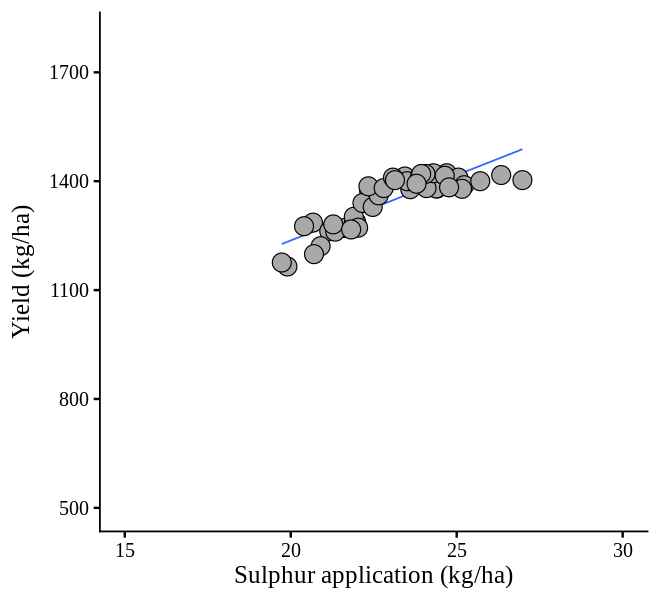

In [22]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

Fig1= ggplot(data=dataA,aes(x=sulphur, y=yield)) +
  geom_smooth(method=lm, level=0.95, se=FALSE, linetype=1, linewidth=0.5, formula= y ~ x) +
  geom_point(aes(shape=variety, fill=variety),col="black", size=5, stroke = 0.5) +
  scale_shape_manual(values=rep(c(21),5)) +
  scale_fill_manual(values=rep(c("dark grey"),5))+
  scale_x_continuous(breaks=seq(15,30,5), limits=c(15,30)) +
  scale_y_continuous(breaks=seq(500,1800,300), limits=c(500,1800)) +
  labs(x="Sulphur application (kg/ha)", y="Yield (kg/ha)") +
  theme_classic(base_size=15, base_family="serif") +
  theme(legend.position="none",
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=5.5, repr.plot.height=5)
print(Fig1)

ggsave("Fig1.png", plot= Fig1, width=5.5, height=5, dpi= 300)

In [23]:
regression= lm (yield~sulphur,data=dataA)
summary(regression)


Call:
lm(formula = yield ~ sulphur, data = dataA)

Residuals:
    Min      1Q  Median      3Q     Max 
-85.236 -25.614  -1.877  30.319  64.933 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  516.204     78.601   6.567 5.46e-08 ***
sulphur       36.028      3.402  10.591 1.47e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 38.79 on 43 degrees of freedom
Multiple R-squared:  0.7229,	Adjusted R-squared:  0.7164 
F-statistic: 112.2 on 1 and 43 DF,  p-value: 1.467e-13


# linear plateau model

# find reasonable initial values for parameters

In [24]:
fit.lm= lm(yield~sulphur,data=dataA)
a_parameter= fit.lm$coefficients[1]
b_parameter= fit.lm$coefficients[2]
x_mean= mean(dataA$sulphur)

a_parameter
b_parameter
x_mean

(Intercept) 
   516.2043

sulphur 
36.02786

[1] 23.04378

# define linear plateau function

In [25]:
#a = intercept
#b = slope
#jp = join point or break point

linplat= function(x, a, b, jp){
         ifelse(x<jp,
                a+b*x,
                a+b*jp)
}

# find best fit parameters

In [26]:
model= nls(yield~linplat(sulphur, a, b, jp),
            data=dataA,
            start=list(a=a_parameter,
                       b=b_parameter,
                       jp=x_mean),
            trace=FALSE,
            nls.control(maxiter=1000))

summary(model)


Formula: yield ~ linplat(sulphur, a, b, jp)

Parameters:
    Estimate Std. Error t value Pr(>|t|)    
a  -125.3667   115.2847  -1.087    0.283    
b    65.5958     5.3061  12.362 1.39e-15 ***
jp   23.2722     0.1683 138.276  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 24.34 on 42 degrees of freedom

Number of iterations to convergence: 4 
Achieved convergence tolerance: 3.495e-09


In [27]:
if(!require(minpack.lm)) install.packages("minpack.lm")
library(minpack.lm)

model= nlsLM(formula= yield ~ linplat(sulphur, a, b, jp),
             data= dataA,
             start=list(a=a_parameter,
                        b=b_parameter,
                        jp=x_mean))

summary(model)


Formula: yield ~ linplat(sulphur, a, b, jp)

Parameters:
               Estimate Std. Error t value Pr(>|t|)    
a.(Intercept) -125.3667   115.2846  -1.087    0.283    
b.sulphur       65.5958     5.3061  12.362 1.39e-15 ***
jp              23.2722     0.1683 138.276  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 24.34 on 42 degrees of freedom

Number of iterations to convergence: 6 
Achieved convergence tolerance: 1.49e-08


In [28]:
if(!require(nlraa)) install.packages("nlraa")
library(nlraa)

model= nlsLM(formula=yield~SSlinp(sulphur,a,b,jp),data=dataA)
summary(model)


Formula: yield ~ SSlinp(sulphur, a, b, jp)

Parameters:
    Estimate Std. Error t value Pr(>|t|)    
a  -125.3667   115.2847  -1.087    0.283    
b    65.5958     5.3061  12.362 1.39e-15 ***
jp   23.2722     0.1683 138.276  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 24.34 on 42 degrees of freedom

Number of iterations to convergence: 2 
Achieved convergence tolerance: 1.49e-08


# create a graph

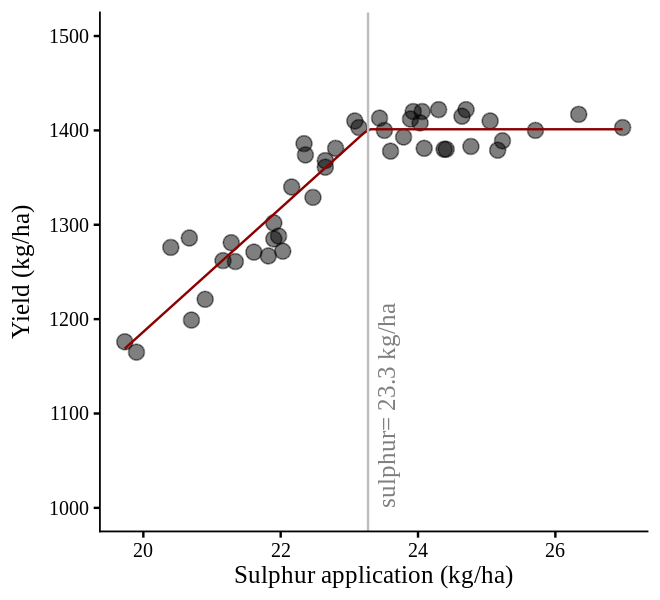

In [29]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)
if(!require(dplyr)) install.packages("dplyr")
library(dplyr)
if(!require(minpack.lm)) install.packages("minpack.lm")
library(minpack.lm)
if(!require(nlraa)) install.packages("nlraa")
library(nlraa)

Fig2= dataA %>%
  ggplot(aes(sulphur, yield)) +
  geom_point(size=4, alpha = 0.5) +
  geom_line(stat="smooth",
            method="nlsLM",
            formula=y~SSlinp(x,a,b,jp),
            se=FALSE,
            color="darkred") +
  geom_vline(xintercept=23.2722, linetype="solid", color="grey") +
  annotate("text", label=paste("sulphur=","23.3","kg/ha"), x=23.3, y=1000,
         angle=90, hjust=0, vjust=1.5, alpha=0.5)+
  scale_y_continuous(breaks=seq(1000, 1500, 100), limits= c(1000, 1500)) +
  labs(x="Sulphur application (kg/ha)", y="Yield (kg/ha)") +
  theme_classic(base_size=15, base_family="serif") +
  theme(legend.position="none",
        axis.line=element_line(size=0.5, colour="black"))

options(repr.plot.width=5.5, repr.plot.height=5)
print(Fig2)

ggsave("Fig2.png", plot= Fig2, width=5.5, height=5, dpi= 300)

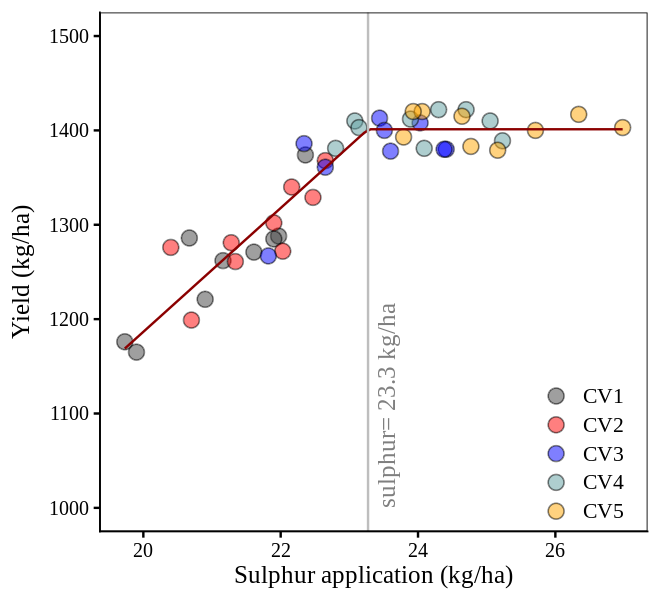

In [30]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)
if(!require(dplyr)) install.packages("dplyr")
library(dplyr)
if(!require(minpack.lm)) install.packages("minpack.lm")
library(minpack.lm)
if(!require(nlraa)) install.packages("nlraa")
library(nlraa)

Fig2A= dataA %>%
  ggplot(aes(sulphur, yield)) +
  geom_point(aes(fill=variety, shape=variety), size=4, alpha = 0.5) +
  scale_fill_manual(values=c("grey25","red","blue","cadetblue","orange"))+
  scale_shape_manual(values=c(21,21,21,21,21))+
  geom_line(stat="smooth",
            method="nlsLM",
            formula=y~SSlinp(x,a,b,jp),
            se=FALSE,
            color="darkred") +
  geom_vline(xintercept=23.2722, linetype="solid", color="grey") +
  annotate("text", label=paste("sulphur=","23.3","kg/ha"), x=23.3, y=1000,
         angle=90, hjust=0, vjust=1.5, alpha=0.5)+
  scale_y_continuous(breaks=seq(1000, 1500, 100), limits= c(1000, 1500)) +
  labs(x="Sulphur application (kg/ha)", y="Yield (kg/ha)") +
  theme_classic(base_size=15, base_family="serif") +
  theme(legend.position=c(0.88,0.15),
        legend.title=element_blank(),
        legend.key=element_rect(color="white", fill=alpha(0.5)),
        legend.text=element_text(family="serif", face="plain",
        size=13, color="black"),
        legend.background= element_rect(fill=alpha(0.5)),
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        axis.line= element_line(linewidth=0.5, colour="black"),
        strip.background=element_rect(color="white",
        linewidth=0.5, linetype="solid"))

options(repr.plot.width=5.5, repr.plot.height=5)
print(Fig2A)

ggsave("Fig2A.png", plot= Fig2, width=5.5, height=5, dpi= 300)

# p-value and pseudo R-squared

In [31]:
# Define null model
nullfunct= function(x, m){m}
m.ini= mean(dataA$sulphur)
null= nls(yield~nullfunct(sulphur, m),
          data=dataA,
          start=list(m=m.ini),
          trace=FALSE,
          nls.control(maxiter=1000))

# Find p-value and pseudo R-squared
if(!require(rcompanion)) install.packages("rcompanion")
library(rcompanion)

print(nagelkerke(model,null))

$Models
                                                                                                                                            
Model: "nlsLM, yield ~ SSlinp(sulphur, a, b, jp), dataA, LM, list(50, 1e-05, 0.0009765625, FALSE, FALSE, 0, FALSE), FALSE"                  
Null:  "nls, yield ~ nullfunct(sulphur, m), dataA, list(m = m.ini), list(1000, 1e-05, 0.0009765625, FALSE, FALSE, 0, FALSE), FALSE, default"

$Pseudo.R.squared.for.model.vs.null
                             Pseudo.R.squared
McFadden                             0.196568
Cox and Snell (ML)                   0.893469
Nagelkerke (Cragg and Uhler)         0.893479

$Likelihood.ratio.test
 Df.diff LogLik.diff  Chisq    p.value
      -2     -50.385 100.77 1.3127e-22

$Number.of.observations
         
Model: 45
Null:  45

$Messages
[1] "Note: For models fit with REML, these statistics are based on refitting with ML"

$Warnings
[1] "None"



# full code


Formula: yield ~ linplat(sulphur, a, b, jp)

Parameters:
    Estimate Std. Error t value Pr(>|t|)    
a  -125.3667   115.2847  -1.087    0.283    
b    65.5958     5.3061  12.362 1.39e-15 ***
jp   23.2722     0.1683 138.276  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 24.34 on 42 degrees of freedom

Number of iterations to convergence: 4 
Achieved convergence tolerance: 3.495e-09


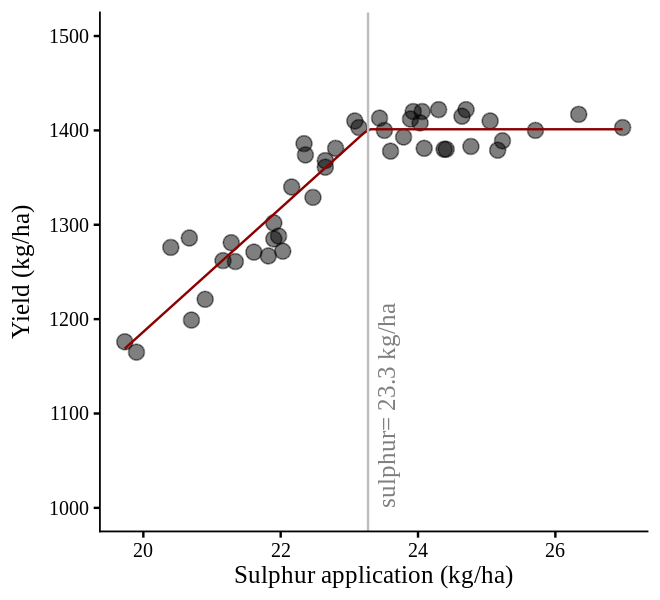

In [32]:
# upload required libraries
if(!require(readr)) install.packages("readr")
library (readr)
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)
if(!require(dplyr)) install.packages("dplyr")
library(dplyr)
if(!require(minpack.lm)) install.packages("minpack.lm")
library(minpack.lm)
if(!require(nlraa)) install.packages("nlraa")
library(nlraa)

# upload data
github= paste0("https://raw.githubusercontent.com/agronomy4future/",
                "raw_data_practice/main/sulphur%20application.csv")
dataA=data.frame(read_csv(url(github), show_col_types= FALSE))

# Find reasonable initial values for parameters
fit.lm= lm(yield~sulphur,data=dataA)
a_parameter= fit.lm$coefficients[1]
b_parameter= fit.lm$coefficients[2]
x_mean= mean(dataA$sulphur)

# Define linear plateau function
#a = intercept
#b = slope
#jp = join point or break point

linplat= function(x, a, b, jp){
         ifelse(x<jp,
                a+b*x,
                a+b*jp)
}

# Find best fit parameters
model= nls(yield~linplat(sulphur, a, b, jp),
            data=dataA,
            start=list(a=a_parameter,
                       b=b_parameter,
                       jp=x_mean),
            trace=FALSE,
            nls.control(maxiter=1000))
summary(model)

# Create a graph
dataA %>%
  ggplot(aes(sulphur, yield)) +
  geom_point(size=4, alpha = 0.5) +
  geom_line(stat="smooth",
            method="nlsLM",
            formula=y~SSlinp(x,a,b,jp),
            se=FALSE,
            color="darkred") +
  geom_vline(xintercept=23.2722, linetype="solid", color="grey") +
  annotate("text", label=paste("sulphur=","23.3","kg/ha"), x=23.3, y=1000,
         angle=90, hjust=0, vjust=1.5, alpha=0.5)+
  scale_y_continuous(breaks=seq(1000, 1500, 100), limits= c(1000, 1500)) +
  labs(x="Sulphur application (kg/ha)", y="Yield (kg/ha)") +
  theme_classic(base_size=15, base_family="serif") +
  theme(legend.position="none",
        axis.line=element_line(size=0.5, colour="black"))

# Alternative method - geom_line

In [45]:
fit.lm= lm(yield~sulphur,data=dataA)
a_parameter= fit.lm$coefficients[1]
b_parameter= fit.lm$coefficients[2]
x_mean= mean(dataA$sulphur)

In [ ]:
# Fit the model
if(!require(minpack.lm)) install.packages("minpack.lm")
library(minpack.lm)

linplat= function(x, a, b, jp){ifelse(x<jp, a+b*x, a+b*jp)}
model= nls(data=dataA, yield~linplat(sulphur, a, b, jp),
       start=list(a=a_parameter, b=b_parameter, jp=x_mean),
       trace=FALSE, nls.control(maxiter=1000))

In [47]:
# Predict and evalulate
pred_lp = data.frame(sulphur = seq(19, 27, 0.1))
pred_lp$yield = predict(model, newdata = pred_lp)
print(head(pred_lp, 5))

  sulphur    yield
1    19.0 1120.954
2    19.1 1127.514
3    19.2 1134.073
4    19.3 1140.633
5    19.4 1147.192


In [34]:
jp_val = round(coef(model)["jp"], 1)
print(jp_val)

  jp 
23.3 


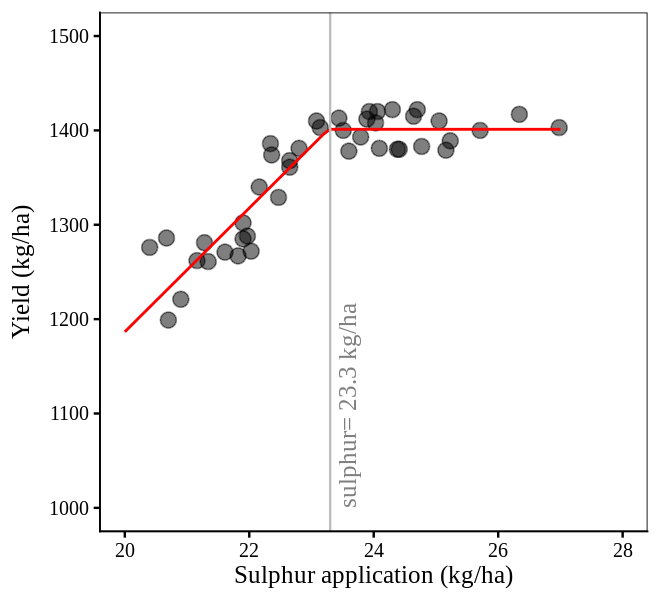

In [35]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)
if(!require(dplyr)) install.packages("dplyr")
library(dplyr)
if(!require(minpack.lm)) install.packages("minpack.lm")
library(minpack.lm)
if(!require(nlraa)) install.packages("nlraa")
library(nlraa)

Fig3=ggplot(data=dataA, aes(x=sulphur, y=yield)) +
  geom_point(size=4, alpha = 0.5, na.rm = TRUE) +
  geom_line(data = pred_lp, color= "red", linewidth= 0.8, na.rm = TRUE) +
  geom_vline(xintercept=jp_val, linetype="solid", color="grey") +
  annotate("text", label=paste("sulphur=","23.3","kg/ha"), x=23.3, y=1000,
           angle=90, hjust=0, vjust=1.5, alpha=0.5, na.rm = TRUE)+
  scale_x_continuous(breaks=seq(20, 28, 2), limits= c(20, 28)) +
  scale_y_continuous(breaks=seq(1000, 1500, 100), limits= c(1000, 1500)) +
  labs(x="Sulphur application (kg/ha)", y="Yield (kg/ha)") +
  theme_classic(base_size=15, base_family="serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        axis.line= element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=5.5, repr.plot.height=5)
print(Fig3)

ggsave("Fig3.png", plot= Fig3, width=5.5, height=5, dpi= 300)

In [36]:
rmse = sqrt(mean(residuals(model)^2))
nrmse = rmse / (max(dataA$yield) - min(dataA$yield))
print(rmse)
print(nrmse)

[1] 23.51083
[1] 0.09148182


# Alternative method - geom_line with grouping

In [37]:
dataAMean= dataA %>%
       group_by(variety) %>%
       dplyr::summarize(
       across(
        .cols= c(yield, sulphur),
        .fns= list(
         Mean= ~mean(., na.rm= TRUE),
         n= ~length(.),
         se= ~sd(., na.rm= TRUE) / sqrt(length(.)))),
        .groups= "drop") %>%
        as.data.frame()

print(head(dataAMean, 3))

  variety yield_Mean yield_n yield_se sulphur_Mean sulphur_n sulphur_se
1     CV1   1258.667       9 21.34114     21.13333         9  0.3068659
2     CV2   1292.000       9 16.63998     21.65889         9  0.2591838
3     CV3   1374.778       9 14.52849     23.35333         9  0.3026274


In [38]:
# Grouping for average
dataAMean= dataA %>%
       group_by(variety) %>%
       dplyr::summarize(
       across(
        .cols= c(yield, sulphur),
        .fns= list(
         Mean= ~mean(., na.rm= TRUE),
         n= ~length(.),
         se= ~sd(., na.rm= TRUE) / sqrt(length(.)))),
        .groups= "drop") %>%
        as.data.frame()
print(dataAMean)

# Find reasonable initial values for parameters
fit.lm= lm(yield_Mean~sulphur_Mean, data= dataAMean)
a_parameter= fit.lm$coefficients[1]
b_parameter= fit.lm$coefficients[2]
x_mean= mean(dataAMean$sulphur_Mean)

# Fit the model
linplat= function(x, a, b, jp){ifelse(x<jp, a+b*x, a+b*jp)}
model= nls(data=dataAMean, yield_Mean~linplat(sulphur_Mean, a, b, jp),
       start=list(a=a_parameter, b=b_parameter, jp=x_mean),
       trace=FALSE, nls.control(maxiter=1000))
summary(model)

# Predict and evalulate
pred_lp = data.frame(sulphur_Mean = seq(19, 27, 0.1))
pred_lp$yield_Mean = predict(model, newdata= pred_lp)

  variety yield_Mean yield_n  yield_se sulphur_Mean sulphur_n sulphur_se
1     CV1   1258.667       9 21.341144     21.13333         9  0.3068659
2     CV2   1292.000       9 16.639979     21.65889         9  0.2591838
3     CV3   1374.778       9 14.528495     23.35333         9  0.3026274
4     CV4   1403.333       9  5.354126     24.03111         9  0.2942242
5     CV5   1403.333       9  5.273097     25.04222         9  0.3708990



Formula: yield_Mean ~ linplat(sulphur_Mean, a, b, jp)

Parameters:
    Estimate Std. Error t value Pr(>|t|)    
a  173.94831   43.43325   4.005  0.05706 .  
b   51.45621    1.96808  26.145  0.00146 ** 
jp  23.89187    0.09084 263.002 1.45e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.229 on 2 degrees of freedom

Number of iterations to convergence: 3 
Achieved convergence tolerance: 9.896e-07


In [39]:
print(head(pred_lp, 5))

  sulphur_Mean yield_Mean
1         19.0   1151.616
2         19.1   1156.762
3         19.2   1161.908
4         19.3   1167.053
5         19.4   1172.199


In [40]:
jp_val = round(coef(model)["jp"], 1)
print(jp_val)

  jp 
23.9 


In [41]:
rmse = sqrt(mean(residuals(model)^2))
nrmse = rmse / (max(dataAMean$yield_Mean) - min(dataAMean$yield_Mean))
print(rmse)
print(nrmse)

[1] 2.042223
[1] 0.01411675


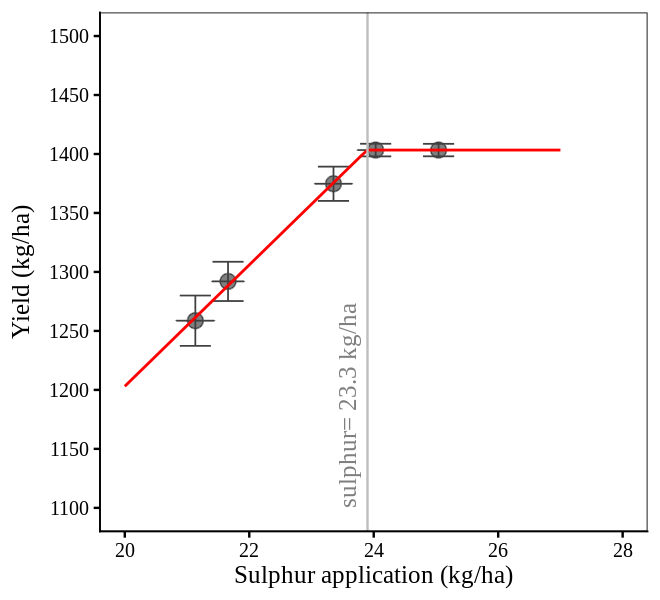

In [42]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)
if(!require(dplyr)) install.packages("dplyr")
library(dplyr)
if(!require(minpack.lm)) install.packages("minpack.lm")
library(minpack.lm)
if(!require(nlraa)) install.packages("nlraa")
library(nlraa)

Fig4=ggplot(data=dataAMean, aes(x= sulphur_Mean, y= yield_Mean)) +
  geom_point(size=4, alpha = 0.5, na.rm = TRUE) +

  geom_errorbar(aes(xmin=sulphur_Mean-sulphur_se,
                    xmax=sulphur_Mean+sulphur_se),
                    position = position_dodge(0.9),
                    linewidth=0.5, width=0.5, color="grey25") +

  geom_errorbar(aes(ymin=yield_Mean-yield_se,
                    ymax=yield_Mean+yield_se),
                    position = position_dodge(0.9),
                    linewidth=0.5, width=0.5, color="grey25") +

  geom_line(data= pred_lp, color = "red", linewidth = 0.8, na.rm = TRUE) +
  geom_vline(xintercept=jp_val, linetype="solid", color="grey", na.rm = TRUE) +
  annotate("text", label=paste("sulphur=","23.3","kg/ha"), x=23.3, y=1100,
           angle=90, hjust=0, vjust=1.5, alpha=0.5, na.rm = TRUE)+
  scale_x_continuous(breaks=seq(20, 28, 2), limits= c(20, 28)) +
  scale_y_continuous(breaks=seq(1100, 1500, 50), limits= c(1100, 1500)) +
  labs(x="Sulphur application (kg/ha)", y="Yield (kg/ha)") +
  theme_classic(base_size=15, base_family="serif") +
  theme(legend.position="none",
        legend.title=element_blank(),
        legend.key=element_rect(color="white", fill=alpha(0.5)),
        legend.text=element_text(family="serif", face="plain",
        size=13, color="black"),
        legend.background= element_rect(fill=alpha(0.5)),
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        axis.line= element_line(linewidth=0.5, colour="black"),
        strip.background=element_rect(color="white",
        linewidth=0.5, linetype="solid"))

options(repr.plot.width=5.5, repr.plot.height=5)
print(Fig4)

ggsave("Fig4.png", plot= Fig4, width=5.5, height=5, dpi= 300)